In [2]:
from auditoryforage.utils import open_pickle_file
file_name = '../data_files/compiled/3_data_behavior.pkl'
compiled_data = open_pickle_file(file_name)

In [3]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

# from irc.manager import IRCManager

# ############

# defaults = {
#     'agent.env._target_': 'auditoryforage.AF_env.AuditoryForaging',
#     'agent.model._target_': 'irc.model.FuncBeliefModel',
# }
# manager = IRCManager(defaults=defaults)

############

def count_no_elements(np_array, min_allowed, max_allowed):
    return len([elt for elt in list(np_array.flatten()) if elt >= min_allowed and elt <= max_allowed])

############

from auditoryforage.AF_env import AuditoryForaging
# env_param = [lick_cost, food_reward, attention_cost_coeff, attention_cost_temp, penalty_cost, iti_cost]
# env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5]}})
env = AuditoryForaging()


hit_count_list = []
miss_count_list = []
false_alarm_list = []
noise_time_before_lick_list = []
signal_time_before_lick_list = []
total_noise_time_list = []
total_signal_time_list = []

analysis_report = {}

for mouse in compiled_data:
    analysis_report[mouse] = {}
    for block_index in compiled_data[mouse]:
        analysis_report[mouse][block_index] = {}
        hit_count = 0 
        miss_count = 0 
        false_alarm_count = 0 
        noise_time_before_lick = 0 
        signal_time_before_lick = 0 
        total_noise_time = 0 
        total_signal_time = 0
        for trial in compiled_data[mouse][block_index]:
            if trial['rewards'][-1] > 0:
                hit_count += 1
                signal_time_before_lick += count_no_elements(trial['states'], 1, env.no_signal_nodes)
            elif trial['states'][-1] > env.no_signal_nodes + 1:
                miss_count += 1
            elif trial['states'][-1] == env.no_signal_nodes + 1:
                false_alarm_count += 1
                noise_time_before_lick += count_no_elements(trial['states'], 0, 0)
            else:
                print("Error somewhere")
            total_signal_time += count_no_elements(trial['states'], 1, env.no_signal_nodes)
            total_noise_time += count_no_elements(trial['states'], 0, 0)
        analysis_report[mouse][block_index]['hit_count'] = hit_count
        analysis_report[mouse][block_index]['miss_count'] = miss_count
        analysis_report[mouse][block_index]['false_alarm_count'] = false_alarm_count
        analysis_report[mouse][block_index]['noise_time_before_lick'] = noise_time_before_lick
        analysis_report[mouse][block_index]['signal_time_before_lick'] = signal_time_before_lick
        analysis_report[mouse][block_index]['total_noise_time'] = total_noise_time
        analysis_report[mouse][block_index]['total_signal_time'] = total_signal_time
        analysis_report[mouse][block_index]['no_trials'] = len(compiled_data[mouse][block_index])

############

from auditoryforage.utils import save_pickle_file

folder_name = './store/'
file_name = folder_name + 'analysis_report.pkl'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
save_pickle_file(analysis_report, file_name)

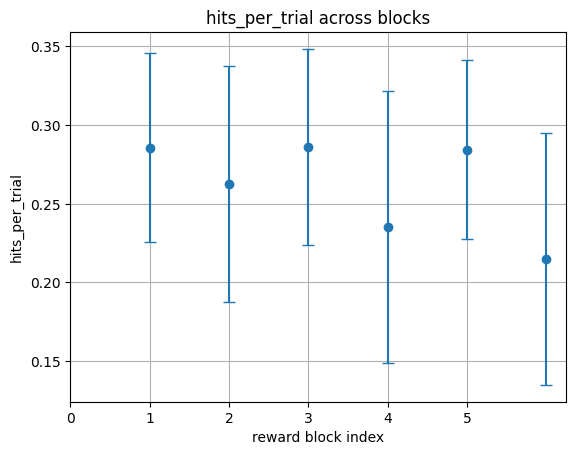

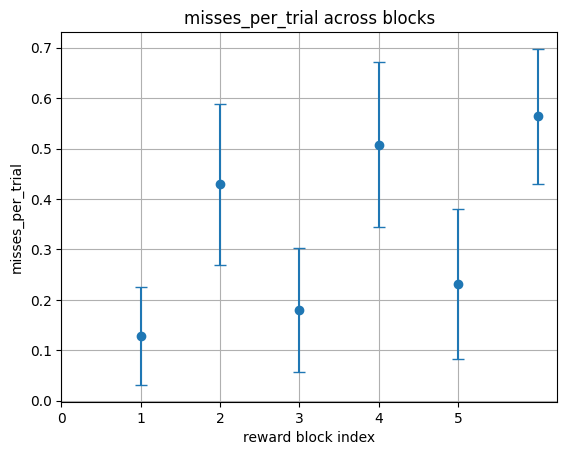

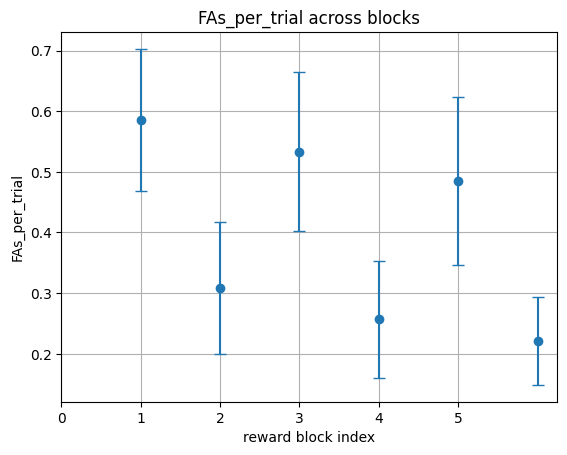

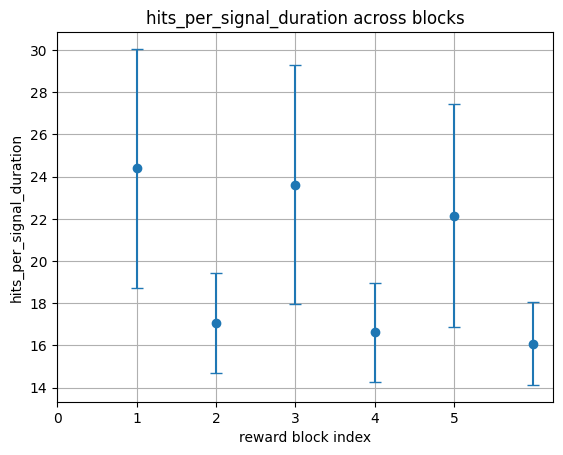

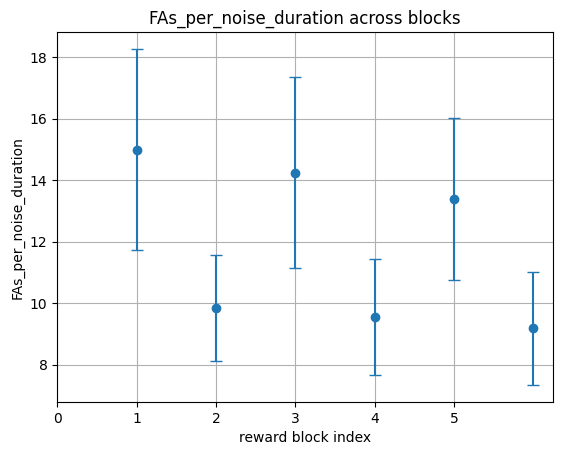

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

one_step_in_seconds = .001

metrics_across_blocks = {}
for mouse in analysis_report.keys(): # for across mice
# for mouse in [list(analysis_report.keys())[6]]: # for single mice
    for reward_block in analysis_report[mouse]:
        if reward_block not in metrics_across_blocks.keys():
            metrics_across_blocks[reward_block] = {}
            metrics_across_blocks[reward_block]['hits_per_trial'] = []
            metrics_across_blocks[reward_block]['misses_per_trial'] = []
            metrics_across_blocks[reward_block]['FAs_per_trial'] = []
            metrics_across_blocks[reward_block]['hits_per_signal_duration'] = []
            metrics_across_blocks[reward_block]['FAs_per_noise_duration'] = []
        hits_per_trial = analysis_report[mouse][reward_block]['hit_count']/analysis_report[mouse][reward_block]['no_trials']
        missess_per_trial = analysis_report[mouse][reward_block]['miss_count']/analysis_report[mouse][reward_block]['no_trials']
        FAs_per_trial = analysis_report[mouse][reward_block]['false_alarm_count']/analysis_report[mouse][reward_block]['no_trials']
        hits_per_signal_duration = analysis_report[mouse][reward_block]['hit_count']/(analysis_report[mouse][reward_block]['signal_time_before_lick'] * one_step_in_seconds)
        FAs_per_noise_duration = analysis_report[mouse][reward_block]['false_alarm_count']/(analysis_report[mouse][reward_block]['noise_time_before_lick'] * one_step_in_seconds)
        metrics_across_blocks[reward_block]['hits_per_trial'].append(hits_per_trial)
        metrics_across_blocks[reward_block]['misses_per_trial'].append(missess_per_trial)
        metrics_across_blocks[reward_block]['FAs_per_trial'].append(FAs_per_trial)
        metrics_across_blocks[reward_block]['hits_per_signal_duration'].append(hits_per_signal_duration)
        metrics_across_blocks[reward_block]['FAs_per_noise_duration'].append(FAs_per_noise_duration)


metrics = ['hits_per_trial', 'misses_per_trial', 'FAs_per_trial', 'hits_per_signal_duration', 'FAs_per_noise_duration']
block_indices_list = ['1.0', '2.0', '3.0', '4.0', '5.0', '6.0']
for metric in metrics:
    plt.figure()
    mean_list = [np.mean(metrics_across_blocks[block_ind][metric]) for block_ind in block_indices_list]
    std_list = [np.std(metrics_across_blocks[block_ind][metric]) for block_ind in block_indices_list]
    plt.errorbar([float(block_ind) for block_ind in block_indices_list], mean_list, yerr= std_list, fmt='o', markersize=6, capsize=4)
    plt.xlabel('reward block index')
    plt.ylabel(metric)
    plt.title(metric + f' across blocks')
    plt.xticks(np.arange(len(block_indices_list)))  # Set x-axis labels to column indices
    plt.grid()
    plt.show()